# Permutation Importance (PIMP) Demo: Waveform-5000

This notebook demonstrates the PIMP algorithm (Altmann et al., 2010,
[doi:10.1093/bioinformatics/btq134](https://doi.org/10.1093/bioinformatics/btq134))
applied to I-ROCKET on the waveform-5000 dataset.

PIMP calculates statistically corrected feature importance. It compares observed importance against a null distribution built from permuted class labels. The result provides a p-value for each feature. This answers a specific question: "Is this feature more important than expected by chance?"

By default, PIMP uses a `RandomForestClassifier` for the importance computation rather than I-ROCKET's Ridge classifier. Tree-based methods can assign exactly zero importance to uninformative features. This produces a sharp, meaningful null distribution. Ridge regularization rarely shrinks coefficients to exactly zero. It also distributes weight across correlated features. Because every feature receives a non-zero weight, distinguishing weak signals from pure noise is difficult without a statistical test.

Please note that this is a much more time intensive procedure compared to feature stability analysis using cross-validation. Typically, one should routinely run the code with 'n_permutations' of 1000 or more to allow for rigorous statistical statements. The lowest possible p-value from _N_ permutations is _1/N_. One hundred permutations only provide a resolution of 0.01. This is too coarse to map the tail of a null distribution accurately. One thousand permutations drop that resolution to 0.001. This size provides stable estimates of the 95th percentile. It avoids the need for complex parametric assumptions about the shape of the null distribution.

The ROCKET convolutional transform is label-independent. The algorithm computes it once and reuses it across all permutations.

## Setup

In [1]:
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
RANDOM_STATE = 42

## Load data

In [2]:
from sklearn.datasets import fetch_openml

waveform = fetch_openml(name='waveform-5000', version=1, as_frame=False)
X = waveform.data[:, :21].astype(np.float32)
y = waveform.target.astype(int)

print(f"Dataset: {X.shape[0]} instances x {X.shape[1]} timepoints")
print(f"Classes: {np.unique(y)}, counts: {np.bincount(y)}")

Dataset: 5000 instances x 21 timepoints
Classes: [0 1 2], counts: [1692 1653 1655]


## Fit I-ROCKET

In [3]:
import interp_rocket as IR

model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

metrics = model.evaluate(X, y)
print(f"\nTraining accuracy: {metrics['accuracy']:.4f}")
print(f"Total features: {model.transform(X[:1]).shape[1]}")

InterpRocket.fit: 5000 instances × 21 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 1176 biases across 2 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 1176 biases across 2 dilations...
  Transforming training data...
  Feature matrix: (5000, 9408)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 0.9776
  Selected alpha: 4832.9302

Training accuracy: 0.9776
Total features: 9408


## Run PIMP

We run 1000 permutations to build the null distribution. Each permutation shuffles the class labels, fits a RandomForestClassifier on the same ROCKET feature matrix, and extracts `feature_importances_`. The p-value for each feature is the fraction of null importances that are at least as large as the observed importance.

In [4]:
pimp = IR.permutation_importance_test(
    model, X, y,
    n_permutations=1000, 
    random_state=RANDOM_STATE,
)

PIMP: 1000 permutations, 9408 features, classifier=RandomForestClassifier
  Permutation 25/1000
  Permutation 50/1000
  Permutation 75/1000
  Permutation 100/1000
  Permutation 125/1000
  Permutation 150/1000
  Permutation 175/1000
  Permutation 200/1000
  Permutation 225/1000
  Permutation 250/1000
  Permutation 275/1000
  Permutation 300/1000
  Permutation 325/1000
  Permutation 350/1000
  Permutation 375/1000
  Permutation 400/1000
  Permutation 425/1000
  Permutation 450/1000
  Permutation 475/1000
  Permutation 500/1000
  Permutation 525/1000
  Permutation 550/1000
  Permutation 575/1000
  Permutation 600/1000
  Permutation 625/1000
  Permutation 650/1000
  Permutation 675/1000
  Permutation 700/1000
  Permutation 725/1000
  Permutation 750/1000
  Permutation 775/1000
  Permutation 800/1000
  Permutation 825/1000
  Permutation 850/1000
  Permutation 875/1000
  Permutation 900/1000
  Permutation 925/1000
  Permutation 950/1000
  Permutation 975/1000
  Permutation 1000/1000

  Signi

## Visualize PIMP results

The bar chart shows observed importance for the top features, colored by significance (blue = significant at p < 0.05, gray = not significant). Red markers show the 95th percentile of the null distribution. The right panel shows the overall p-value distribution.

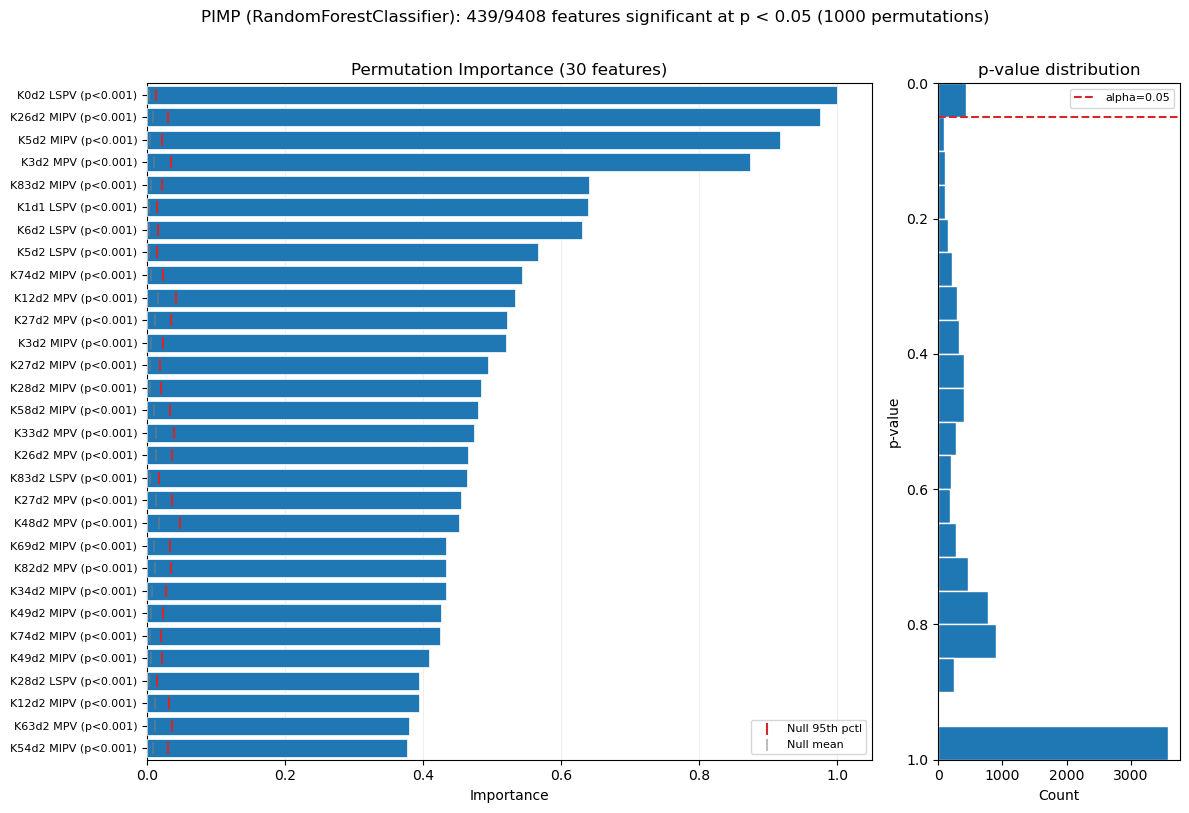

In [5]:
fig = IR.plot_permutation_importance(pimp, model=model, n_show=30)

## Extract significant features

Features with a p-value below 0.05 perform better than chance. This indicates they capture genuine class structure rather than random noise.

In [6]:
sig_features = np.where(pimp['significant_mask'])[0]
print(f"Significant features: {len(sig_features)} / {len(pimp['feature_mask'])}")
print(f"Non-significant: {len(pimp['feature_mask']) - len(sig_features)}")

# Decode the top significant features
sig_importance = pimp['observed_importance'][sig_features]
sig_order = np.argsort(-sig_importance)
top_sig = sig_features[sig_order[:20]]

print(f"\nTop 20 significant features:")
for fi in top_sig:
    info = model.decode_feature_index(int(fi))
    print(f"  F{fi:>5d}  K{info['kernel_index']:>2d} d={info['dilation']:>2d}  "
          f"{info['pooling_op']:>4s}  {info['representation']:>4s}  "
          f"imp={pimp['observed_importance'][fi]:.4f}  "
          f"p={pimp['p_values'][fi]:.3f}")

Significant features: 439 / 9408
Non-significant: 8969

Top 20 significant features:
  F 2371  K 0 d= 2  LSPV   raw  imp=1.0000  p=0.000
  F 3094  K26 d= 2  MIPV   raw  imp=0.9748  p=0.000
  F 2502  K 5 d= 2  MIPV   raw  imp=0.9164  p=0.000
  F 2437  K 3 d= 2   MPV   raw  imp=0.8738  p=0.000
  F 4702  K83 d= 2  MIPV   raw  imp=0.6408  p=0.000
  F   39  K 1 d= 1  LSPV   raw  imp=0.6381  p=0.000
  F 2547  K 6 d= 2  LSPV   raw  imp=0.6298  p=0.000
  F 2515  K 5 d= 2  LSPV   raw  imp=0.5668  p=0.000
  F 4442  K74 d= 2  MIPV   raw  imp=0.5430  p=0.000
  F 2697  K12 d= 2   MPV   raw  imp=0.5328  p=0.000
  F 3113  K27 d= 2   MPV   raw  imp=0.5209  p=0.000
  F 2450  K 3 d= 2  MIPV   raw  imp=0.5194  p=0.000
  F 3130  K27 d= 2  MIPV   raw  imp=0.4942  p=0.000
  F 3162  K28 d= 2  MIPV   raw  imp=0.4833  p=0.000
  F 4002  K58 d= 2  MIPV   raw  imp=0.4790  p=0.000
  F 3293  K33 d= 2   MPV   raw  imp=0.4742  p=0.000
  F 3105  K26 d= 2   MPV   raw  imp=0.4648  p=0.000
  F 4699  K83 d= 2  LSPV   raw 

## Compare PIMP with Feature Stability Analysis

Both methods identify robust features. They approach the problem from different angles. PIMP tests if a feature's importance exceeds random chance. FSA tests if a feature remains important across different data splits. The most trustworthy features pass both tests.

In [7]:
# Run feature stability analysis
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
stable_features = IR.get_stable_features(stability, threshold=0.8)

# Overlap
pimp_set = set(sig_features)
fsa_set = set(stable_features)
overlap = pimp_set & fsa_set

print(f"\nPIMP significant: {len(pimp_set)}")
print(f"FSA stable (>=80%): {len(fsa_set)}")
print(f"Overlap: {len(overlap)}")
print(f"FSA features also significant by PIMP: "
      f"{len(overlap)}/{len(fsa_set)} "
      f"({100*len(overlap)/max(len(fsa_set),1):.0f}%)")

CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 124 features appeared in every round so far
  Round 2/5: 93 features appeared in every round so far
  Round 3/5: 82 features appeared in every round so far
  Round 4/5: 75 features appeared in every round so far
  Round 5/5: 74 features appeared in every round so far

  Features in ALL folds:  3
  Features in ≥80% folds: 19
  Features in NO folds:   9167
Stable features (≥80% of 25 folds): 19

PIMP significant: 439
FSA stable (>=80%): 19
Overlap: 8
FSA features also significant by PIMP: 8/19 (42%)


#### COMMENT

On the waveform dataset, FSA and PIMP identify disjoint feature sets. This reflects the different classifiers used internally: FSA ranks by Ridge coefficients (linear importance), while PIMP ranks by RandomForest splits (non-linear importance). The minimal overlap indicates that the two methods provide complementary rather than confirmatory evidence on this dataset, and others.

## Temporal importance using PIMP-significant features

We can use PIMP-significant features as an alternative feature mask for all downstream I-ROCKET visualizations.

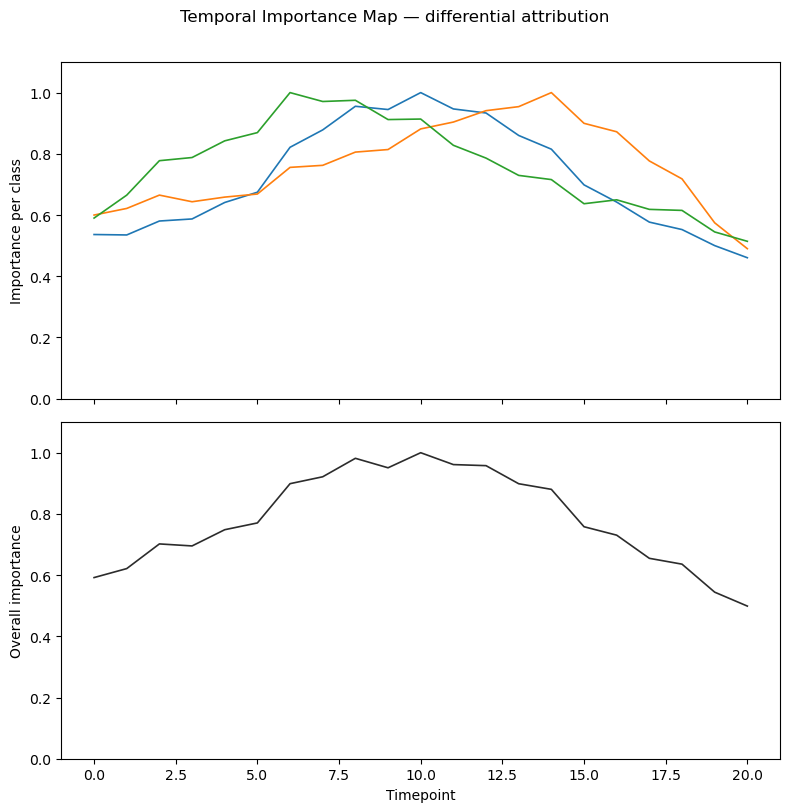

In [8]:
fig, imp = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=sig_features,
    figsize=(8, 8),
)

## Temporal importance using Feature Stability Analysis

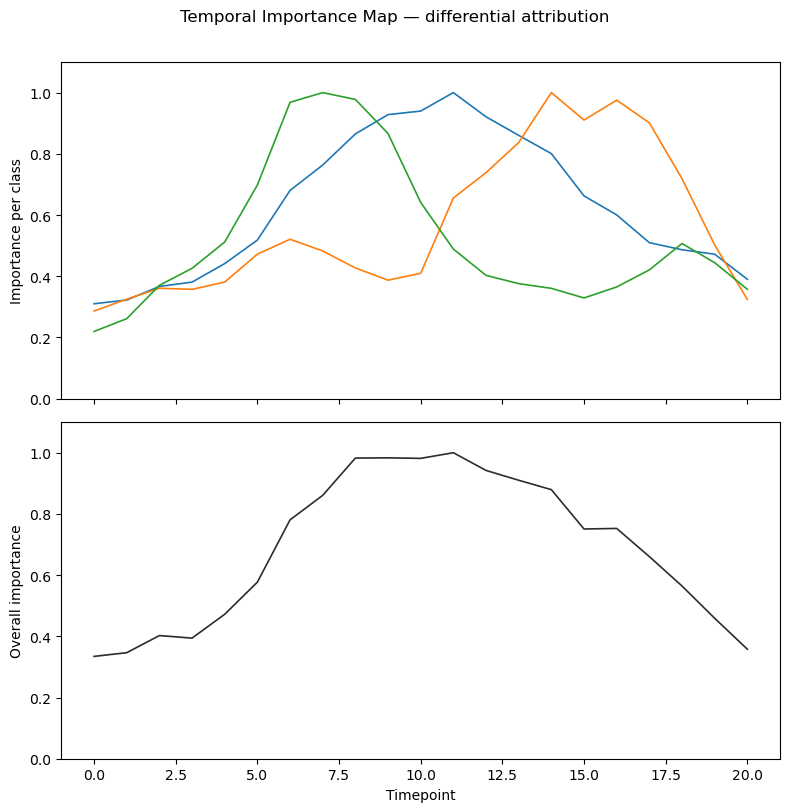

In [9]:
fig, imp = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=stable_features,
    figsize=(8, 8),
)

## Receptive field diagram using PIMP-significant features

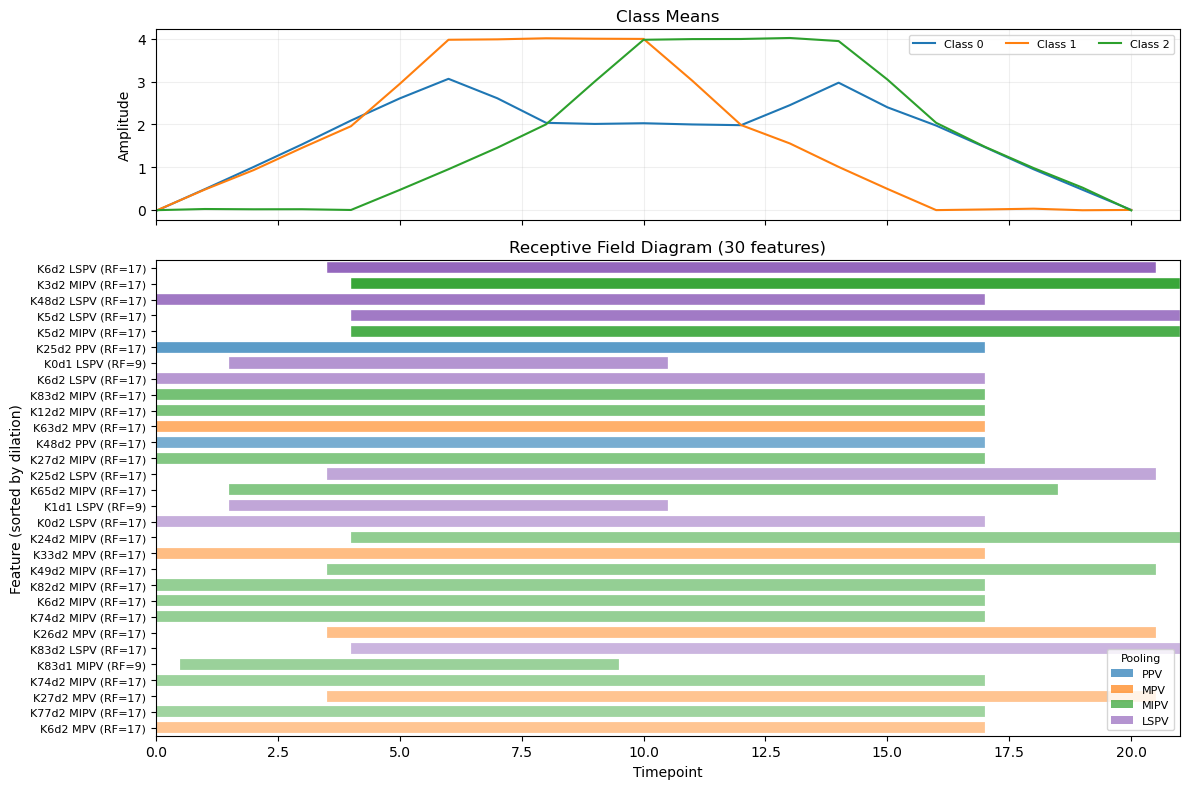

In [10]:
# Use the top 50 significant features by importance for a readable plot
top_50_sig = sig_features[sig_order[:50]]
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=top_50_sig)

## Receptive field diagram using features from FSA

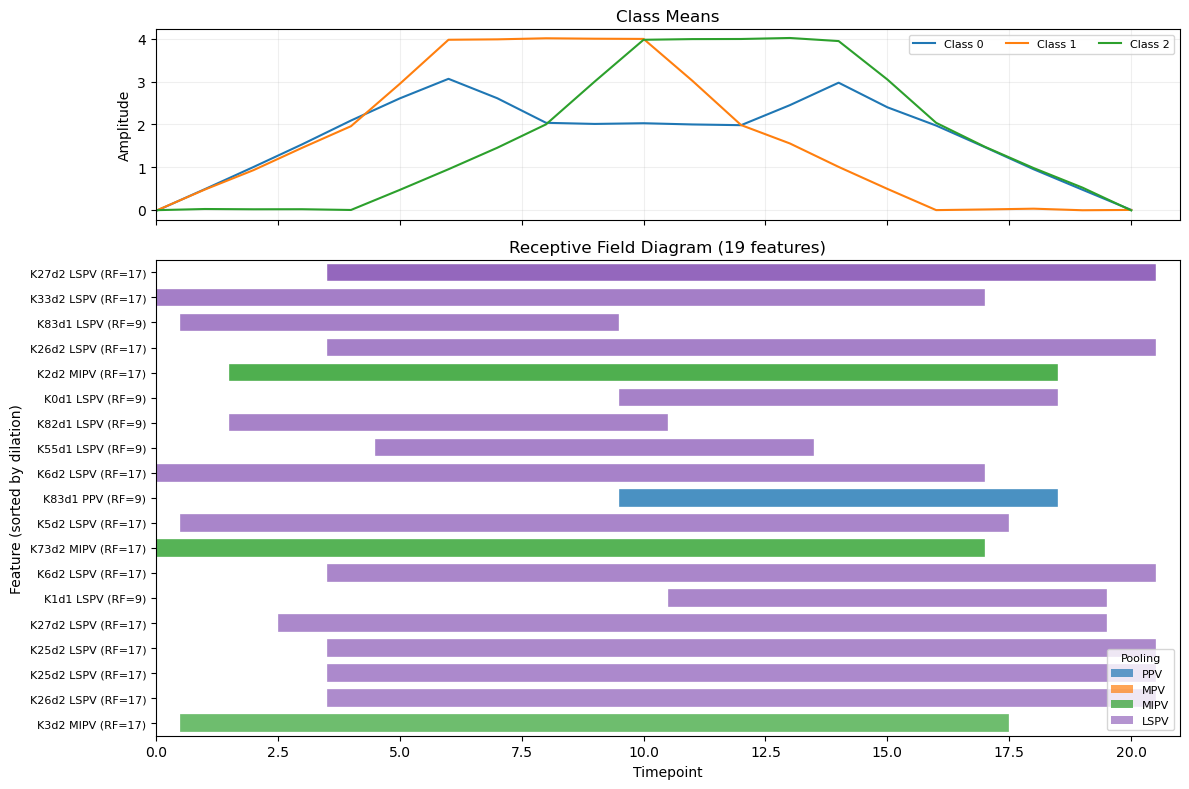

In [11]:
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=stable_features)

## Comparing Feature Stability and Permutation Importance

FSA and PIMP measure different properties of the feature set using different classifiers. FSA ranks features by Ridge coefficient magnitude and identifies those that are consistently highly ranked across cross-validation folds. PIMP ranks features by RandomForest Gini importance and tests whether each feature's importance exceeds a null distribution built from permuted class labels. Because the two methods use different classifiers, they can identify largely non-overlapping feature sets, as observed on the waveform dataset.

Combining them as a sequential pipeline (FSA survivors passed to PIMP) is not recommended. Instead, use FSA and PIMP are independent analyses of your data. FSA selects features for the Ridge-based interpretability pipeline. FSA and PIMP provide two independent analytical paths through the feature space, originating from the same random kernel transform but evaluated by different classifiers (Ridge and RandomForest). The meaningful comparison is not which features overlap, but whether the temporal importance profiles and receptive field maps converge on the same discriminative regions of the signal. Convergence indicates that the discriminative structure is robust to classifier choice. Divergence indicates that the two classifiers exploit different aspects of the signal, which is itself informative about the data.